# Thiết kế class đơn giản

In [1]:
import torch
import torchvision
import torch.nn as nn
import numpy
import matplotlib.pyplot as plt

In [9]:
class LinearModel(nn.Module):
  def __init__(self, input_size, output_size):
    super().__init__()
    self.weight_w = nn.Parameter(torch.randn(output_size, input_size))
    self.weight_b = nn.Parameter(torch.randn(1, output_size))

  def forward(self, x):
    return torch.matmul(x, self.weight_w.t())+self.weight_b

In [10]:
data = torch.randn(100, 5)

linear = LinearModel(5, 1)
output = linear(data)
print(output.shape)

torch.Size([100, 1])


# Xài Layer có sẵn

In [12]:
linear = nn.Linear(5,1)
print('w =', linear.weight.data)
print('b =', linear.bias.data)

w = tensor([[-0.2317, -0.2693, -0.3184,  0.4006, -0.3621]])
b = tensor([0.2566])


In [13]:
#Ban đầu thì backwards đều bằng None chứ không phải bằng 0
print('dy/dw =', linear.weight.grad)
print('dy/db =', linear.bias.grad)

dy/dw = None
dy/db = None


In [15]:
data = torch.randn(100, 5)
# Output phục vụ việc dự đoán
target = data.sum(1, keepdim=True) + torch.randn(data.shape[0], 1)
print('Input', data[:5])
print('Output', target[:5])

Input tensor([[ 0.9386,  0.1294, -0.3275,  0.6815,  0.4144],
        [ 0.7566, -0.3805, -1.1920,  0.0374,  2.5883],
        [-0.1029,  3.0832,  1.3388, -0.7202, -0.7515],
        [ 0.4480, -0.4983,  1.2768, -1.5860,  0.4976],
        [ 0.2761,  0.8210,  1.2053,  0.1321,  0.2346]])
Output tensor([[1.2369],
        [1.9798],
        [2.2130],
        [0.6253],
        [2.7950]])


In [16]:
target_pred = linear(data)
print('Output dự đoán:', target_pred[:10])

Output dự đoán: tensor([[ 0.2315],
        [-0.3591],
        [-0.9926],
        [-0.9351],
        [-0.4443],
        [ 0.1253],
        [-0.8029],
        [ 0.1084],
        [-0.3848],
        [-1.1906]], grad_fn=<SliceBackward0>)


# Loss and optimizers

In [19]:
# Khởi tạo loss function và optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)


Text(0, 0.5, 'Outputs')

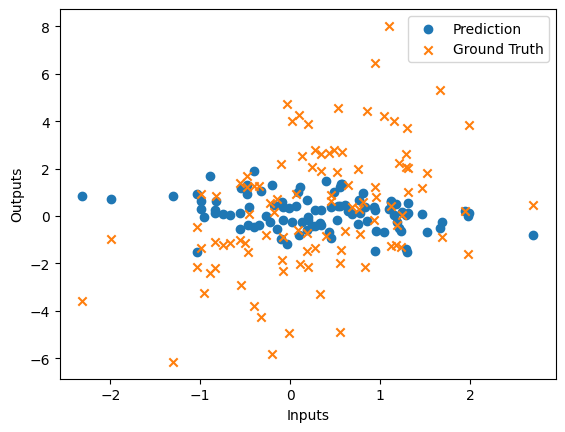

In [20]:
plt.scatter(data[:, 0], target_pred.detach())
plt.scatter(data[:,0], target, marker='x')
plt.legend(['Prediction', 'Ground Truth'])
plt.xlabel('Inputs')
plt.ylabel('Outputs')

In [23]:
# Tính loss ban đầu trước khi optimizer
loss = loss_fn(target_pred, target)
print('Initial Loss:', loss.item())

Initial Loss: 9.091599464416504


In [24]:
# Backward
loss.backward()
print ('dL/dw: ', linear.weight.grad)
print ('dL/db: ', linear.bias.grad)

dL/dw:  tensor([[-2.2827, -2.9858, -2.8548, -1.8209, -3.7349]])
dL/db:  tensor([-0.3143])


In [26]:
# Cập nhật lại parameters
optimizer.step()
target_pred = linear(data)
loss = loss_fn(target_pred, target)
print('w =', linear.weight.data)
print('b =', linear.bias.data)
print('Loss after 1 step optimization', loss.item())

w = tensor([[-0.1861, -0.2096, -0.2613,  0.4371, -0.2874]])
b = tensor([0.2629])
Loss after 1 step optimization 8.31885051727295


# Training loops

In [27]:
logs_logger = []
for i in range(100):
  target_pred = linear(data)
  loss = loss_fn(target_pred, target)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  logs_logger.append(loss.item())

print('Final Loss', loss.item())

Final Loss 0.9384387135505676


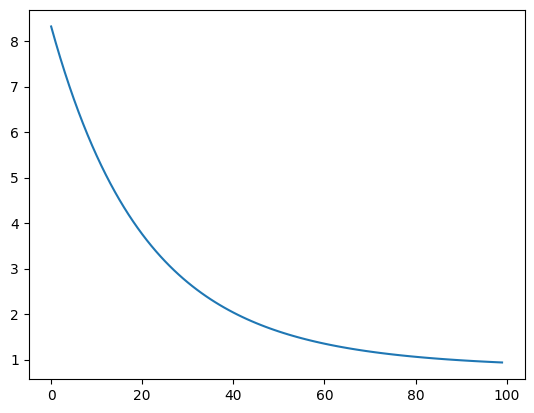

In [30]:
plt.plot(logs_logger);

Text(0, 0.5, 'Outputs')

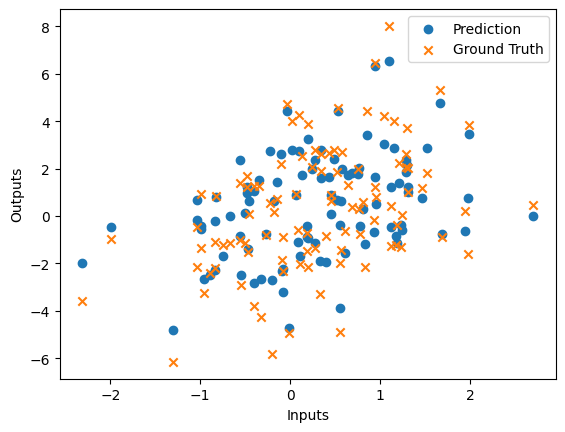

In [28]:
plt.scatter(data[:, 0], target_pred.detach())
plt.scatter(data[:,0], target, marker='x')
plt.legend(['Prediction', 'Ground Truth'])
plt.xlabel('Inputs')
plt.ylabel('Outputs')